In [ ]:
# Batch Training
# 01_xgboost_training.ipynb
# Binary Attack Detection using XGBoost
# ============================================================

# ── CELL 1: Mount Drive & Install Dependencies ──────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install xgboost scikit-learn matplotlib seaborn pandas numpy -q

# ── CELL 2: Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# ── CELL 3: Paths ────────────────────────────────────────────
train_csv   = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv    = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"
output_dir  = "/content/drive/MyDrive/EPdataset/models/xgboost"
plots_dir   = "/content/drive/MyDrive/EPdataset/plots/xgboost"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir,  exist_ok=True)

# ── CELL 4: Feature Columns ──────────────────────────────────
FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'L4_DST_PORT', 'ICMP_TYPE', 'DNS_QUERY_TYPE', 'DNS_QUERY_ID',
    'FTP_COMMAND_RET_CODE'
]
TARGET = 'Label'  # 0 = Benign, 1 = Attack

# ── CELL 5: Load Data in Chunks (RAM safe) ───────────────────
print("Loading training data...")

chunk_size = 1_000_000
X_chunks, y_chunks = [], []

for i, chunk in enumerate(pd.read_csv(train_csv, chunksize=chunk_size, low_memory=False)):
    X_chunks.append(chunk[FEATURES].values)
    y_chunks.append(chunk[TARGET].values)
    print(f"  Loaded chunk {i+1} | rows so far: {sum(len(x) for x in X_chunks):,}")

X_train = np.concatenate(X_chunks, axis=0)
y_train = np.concatenate(y_chunks, axis=0)
del X_chunks, y_chunks
print(f"Train set: {X_train.shape} | Benign: {(y_train==0).sum():,} | Attack: {(y_train==1).sum():,}")

print("\nLoading test data...")
X_chunks, y_chunks = [], []

for i, chunk in enumerate(pd.read_csv(test_csv, chunksize=chunk_size, low_memory=False)):
    X_chunks.append(chunk[FEATURES].values)
    y_chunks.append(chunk[TARGET].values)
    print(f"  Loaded chunk {i+1} | rows so far: {sum(len(x) for x in X_chunks):,}")

X_test = np.concatenate(X_chunks, axis=0)
y_test = np.concatenate(y_chunks, axis=0)
del X_chunks, y_chunks
print(f"Test set:  {X_test.shape} | Benign: {(y_test==0).sum():,} | Attack: {(y_test==1).sum():,}")

# ── CELL 6: Scale Features ───────────────────────────────────
print("\nScaling features...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save scaler — needed for inference pipeline later
scaler_path = os.path.join(output_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")

# ── CELL 7: Class Weight ─────────────────────────────────────
benign_count = (y_train == 0).sum()
attack_count = (y_train == 1).sum()
scale_pos_weight = benign_count / attack_count
print(f"\nscale_pos_weight = {scale_pos_weight:.4f}")

# ── CELL 8: Train XGBoost ────────────────────────────────────
print("\nTraining XGBoost...")

model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    use_label_encoder = False,
    eval_metric       = 'auc',
    early_stopping_rounds = 20,
    random_state      = 42,
    tree_method       = 'hist',   # fast on CPU
    device            = 'cuda'    # uses GPU if available on Colab
)

model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 50
)

# Save model
model_path = os.path.join(output_dir, 'xgboost_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"\nModel saved to {model_path}")

# ── CELL 9: Predictions ──────────────────────────────────────
print("\nGenerating predictions...")
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ── CELL 10: Core Metrics ────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)
ap_score  = average_precision_score(y_test, y_pred_proba)

print("\n========== XGBoost Evaluation ==========")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision         : {prec:.4f}")
print(f"Recall            : {rec:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"AUC-ROC           : {auc_score:.4f}")
print(f"AUC-PR            : {ap_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

# Save metrics to txt for research paper
metrics_path = os.path.join(plots_dir, 'metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("========== XGBoost Evaluation ==========\n")
    f.write(f"Accuracy          : {acc:.4f}\n")
    f.write(f"Precision         : {prec:.4f}\n")
    f.write(f"Recall            : {rec:.4f}\n")
    f.write(f"F1 Score          : {f1:.4f}\n")
    f.write(f"AUC-ROC           : {auc_score:.4f}\n")
    f.write(f"AUC-PR            : {ap_score:.4f}\n\n")
    f.write(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
print(f"\nMetrics saved to {metrics_path}")

# ── CELL 11: Confusion Matrix Plot ───────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('XGBoost — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved.")

# ── CELL 12: AUC-ROC Curve ───────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — AUC-ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_roc_curve.png'), dpi=150)
plt.show()
print("AUC-ROC curve saved.")

# ── CELL 13: AUC-PR Curve ────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2,
         label=f'PR Curve (AUC-PR = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost — Precision-Recall Curve', fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_pr_curve.png'), dpi=150)
plt.show()
print("AUC-PR curve saved.")

# ── CELL 14: Feature Importance Plot ─────────────────────────
importance = model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importance})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'feature_importance.png'), dpi=150)
plt.show()
print("Feature importance plot saved.")

print("\n✅ XGBoost training complete. All outputs saved to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fitting scaler on first chunk...
Scaler saved to /content/drive/MyDrive/EPdataset/models/xgboost/scaler.pkl

Counting class distribution...
Benign : 17,615,706
Attack : 35,575,879
scale_pos_weight : 0.4952

Starting incremental XGBoost training...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Chunk 1 trained | Trees so far: 10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Chunk 2 trained | Trees so far: 20


...

Chunk 53 trained | Trees so far: 530


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Chunk 54 trained | Trees so far: 540

Model saved to /content/drive/MyDrive/EPdataset/models/xgboost/xgboost_model.json

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Evaluation complete.

========== XGBoost Evaluation ==========
Accuracy  : 0.9854
Precision : 0.9950
Recall    : 0.9830
F1 Score  : 0.9890
AUC-ROC   : 0.9987
AUC-PR    : 0.9994

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98   7549589
      Attack       1.00      0.98      0.99  15246802

    accuracy                           0.99  22796391
   macro avg       0.98      0.99      0.98  22796391
weighted avg       0.99      0.99      0.99  22796391

Metrics saved to /content/drive/MyDrive/EPdataset/plots/xgboost/metrics.txt


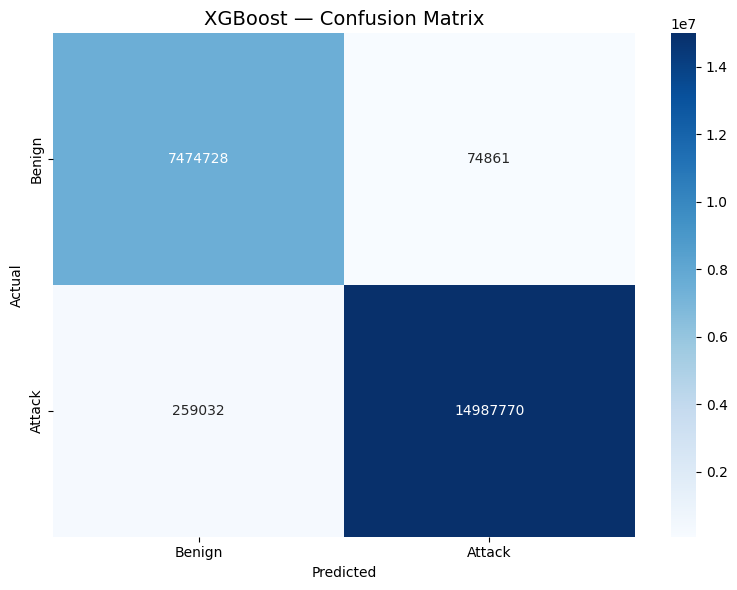

Confusion matrix saved.


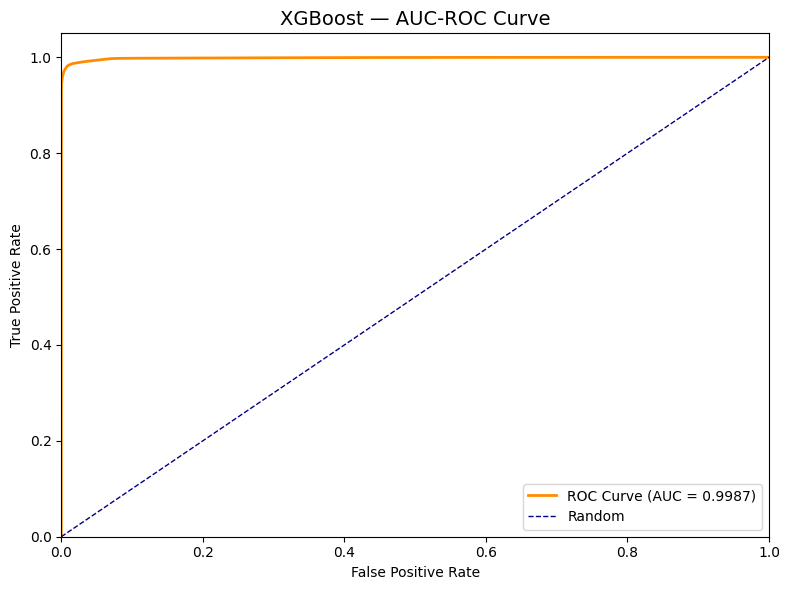

AUC-ROC curve saved.


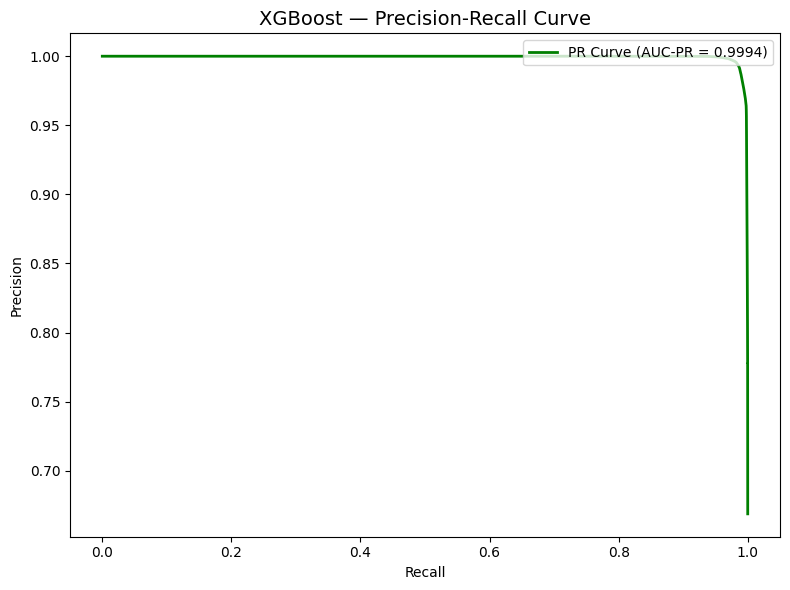

AUC-PR curve saved.


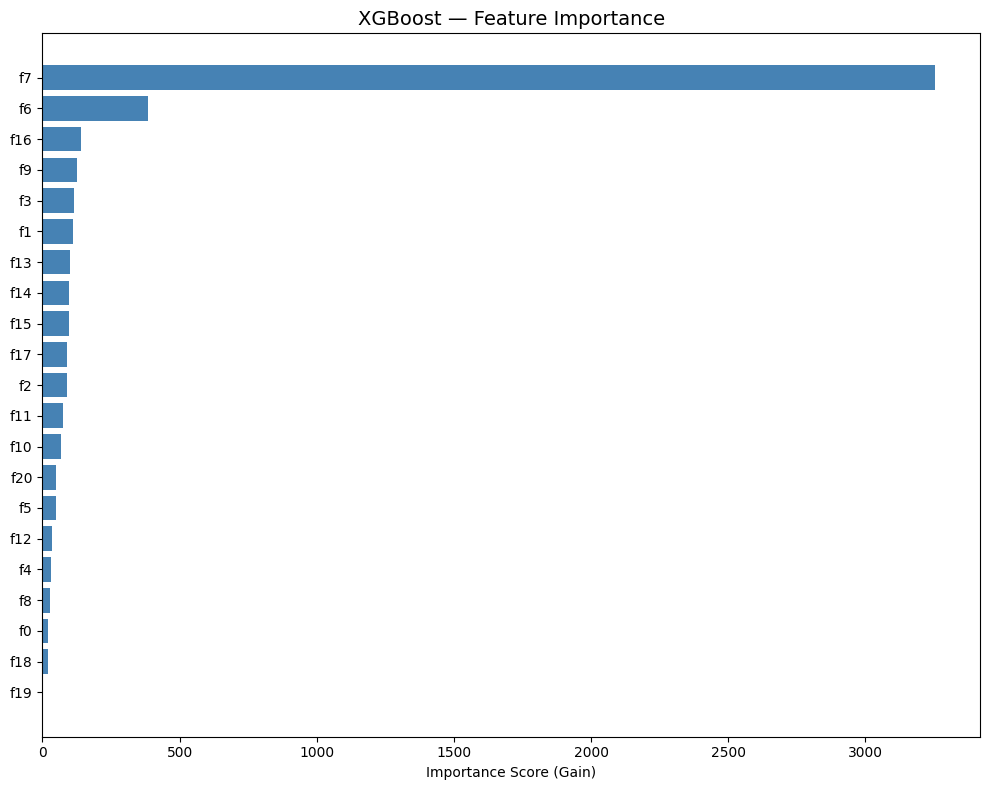

Feature importance saved.

✅ XGBoost training complete. All outputs saved to Drive.


In [1]:
#Incremental Aproach
# ============================================================
# 01_xgboost_training.ipynb
# Binary Attack Detection using XGBoost
# ============================================================

# ── CELL 1: Mount Drive & Install Dependencies ──────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install xgboost scikit-learn matplotlib seaborn pandas numpy -q

# ── CELL 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# ── CELL 3: Paths ────────────────────────────────────────────
train_csv  = "/content/drive/MyDrive/EPdataset/stratified_splits/train.csv"
test_csv   = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"
output_dir = "/content/drive/MyDrive/EPdataset/models/xgboost"
plots_dir  = "/content/drive/MyDrive/EPdataset/plots/xgboost"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir,  exist_ok=True)

# ── CELL 4: Feature Columns ──────────────────────────────────
FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'L4_DST_PORT', 'ICMP_TYPE', 'DNS_QUERY_TYPE', 'DNS_QUERY_ID',
    'FTP_COMMAND_RET_CODE'
]
TARGET = 'Label'  # 0 = Benign, 1 = Attack

# ── CELL 5: Fit Scaler on First Chunk Only ───────────────────
print("Fitting scaler on first chunk...")
first_chunk = pd.read_csv(train_csv, nrows=1_000_000, low_memory=False)
scaler = StandardScaler()
scaler.fit(first_chunk[FEATURES])
del first_chunk

scaler_path = os.path.join(output_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")

# ── CELL 6: Count Class Distribution (lightweight) ───────────
print("\nCounting class distribution...")
benign_count = 0
attack_count = 0
for chunk in pd.read_csv(train_csv, usecols=['Label'], chunksize=1_000_000):
    benign_count += (chunk['Label'] == 0).sum()
    attack_count += (chunk['Label'] == 1).sum()

scale_pos_weight = benign_count / attack_count
print(f"Benign : {benign_count:,}")
print(f"Attack : {attack_count:,}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")

# ── CELL 7: Incremental XGBoost Training ─────────────────────
params = {
    'max_depth'        : 6,
    'learning_rate'    : 0.1,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'scale_pos_weight' : scale_pos_weight,
    'eval_metric'      : 'auc',
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'objective'        : 'binary:logistic',
    'seed'             : 42
}

chunk_size = 1_000_000
num_boost_round_per_chunk = 10
booster = None
total_chunks = 0

print("\nStarting incremental XGBoost training...")
for i, chunk in enumerate(pd.read_csv(train_csv, chunksize=chunk_size, low_memory=False)):
    X = scaler.transform(chunk[FEATURES].values)
    y = chunk[TARGET].values

    dtrain  = xgb.DMatrix(X, label=y)
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round   = num_boost_round_per_chunk,
        xgb_model         = booster,
        verbose_eval      = False
    )

    total_chunks += 1
    del X, y, dtrain, chunk
    print(f"Chunk {i+1} trained | Trees so far: {total_chunks * num_boost_round_per_chunk}")

# Save model
model_path = os.path.join(output_dir, 'xgboost_model.json')
booster.save_model(model_path)
print(f"\nModel saved to {model_path}")

# ── CELL 8: Evaluate on Test Set (chunk by chunk) ────────────
print("\nEvaluating on test set...")
y_test_all  = []
y_pred_all  = []
y_proba_all = []

for chunk in pd.read_csv(test_csv, chunksize=chunk_size, low_memory=False):
    X = scaler.transform(chunk[FEATURES].values)
    y = chunk[TARGET].values

    dtest = xgb.DMatrix(X)
    proba = booster.predict(dtest)
    pred  = (proba >= 0.5).astype(int)

    y_test_all.extend(y)
    y_pred_all.extend(pred)
    y_proba_all.extend(proba)

    del X, y, dtest, chunk

y_test  = np.array(y_test_all)
y_pred  = np.array(y_pred_all)
y_proba = np.array(y_proba_all)
del y_test_all, y_pred_all, y_proba_all
print("Evaluation complete.")

# ── CELL 9: Core Metrics ─────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)
ap_score  = average_precision_score(y_test, y_proba)

print("\n========== XGBoost Evaluation ==========")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_score:.4f}")
print(f"AUC-PR    : {ap_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

metrics_path = os.path.join(plots_dir, 'metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("========== XGBoost Evaluation ==========\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"AUC-ROC   : {auc_score:.4f}\n")
    f.write(f"AUC-PR    : {ap_score:.4f}\n\n")
    f.write(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
print(f"Metrics saved to {metrics_path}")

# ── CELL 10: Confusion Matrix ─────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('XGBoost — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved.")

# ── CELL 11: AUC-ROC Curve ───────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — AUC-ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_roc_curve.png'), dpi=150)
plt.show()
print("AUC-ROC curve saved.")

# ── CELL 12: AUC-PR Curve ────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2,
         label=f'PR Curve (AUC-PR = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost — Precision-Recall Curve', fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'auc_pr_curve.png'), dpi=150)
plt.show()
print("AUC-PR curve saved.")

# ── CELL 13: Feature Importance ──────────────────────────────
importance = booster.get_score(importance_type='gain')
feat_df = pd.DataFrame({
    'Feature'   : list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score (Gain)')
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'feature_importance.png'), dpi=150)
plt.show()
print("Feature importance saved.")

print("\n✅ XGBoost training complete. All outputs saved to Drive.")

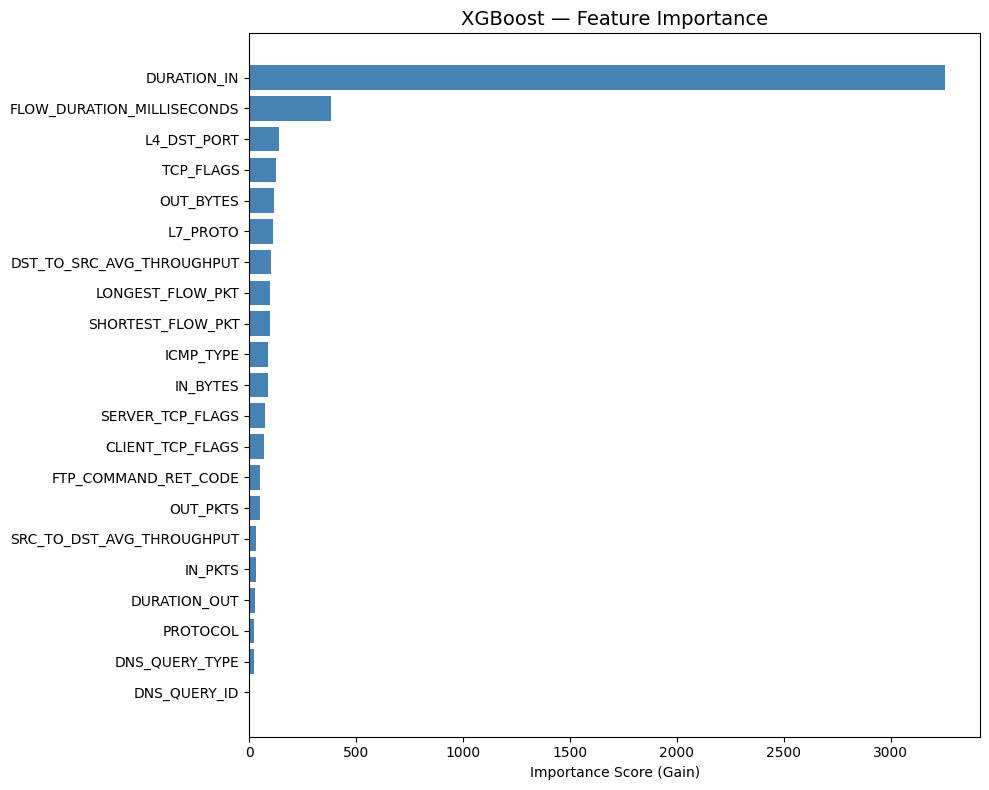

In [2]:
# Map f0, f1... back to actual feature names and regenerate plot
importance = booster.get_score(importance_type='gain')

# Replace f0->PROTOCOL, f1->L7_PROTO etc.
feature_map = {f'f{i}': name for i, name in enumerate(FEATURES)}
importance_named = {feature_map.get(k, k): v for k, v in importance.items()}

feat_df = pd.DataFrame({
    'Feature'   : list(importance_named.keys()),
    'Importance': list(importance_named.values())
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score (Gain)')
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'feature_importance.png'), dpi=150)
plt.show()